 Mount Drive & Import Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/sentiment-robustness-id/src')
from config import *

print(f'ROOT : {ROOT}')
print('✅ Config loaded')

Mounted at /content/drive
ROOT : /content/drive/MyDrive/sentiment-robustness-id
✅ Config loaded


 Copy Dataset ke Lokal Colab

In [2]:
# ============================================================
# Copy dataset dari Google Drive ke lokal Colab
# Hanya file yang dibutuhkan untuk training & evaluasi
# Output (model, hasil) tetap disimpan ke Drive
# ============================================================

import shutil
import time
import os

LOCAL_ROOT = '/content/local_project'

files_to_copy = {
    'processed'  : (PROCESSED_DATA_PATH, f'{LOCAL_ROOT}/data/processed/data_clean.csv'),
    'test_clean' : (TEST_CLEAN_PATH,     f'{LOCAL_ROOT}/data/noisy/test_clean.csv'),
    'noise_10'   : (TEST_NOISE_10_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_10.csv'),
    'noise_20'   : (TEST_NOISE_20_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_20.csv'),
    'noise_30'   : (TEST_NOISE_30_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_30.csv'),
}

for folder in [
    f'{LOCAL_ROOT}/data/processed',
    f'{LOCAL_ROOT}/data/noisy',
    f'{LOCAL_ROOT}/models',
]:
    os.makedirs(folder, exist_ok=True)

print('=== COPYING DATASET TO LOCAL COLAB ===\n')
for name, (src, dst) in files_to_copy.items():
    t0      = time.time()
    shutil.copy2(src, dst)
    size_mb = os.path.getsize(dst) / (1024 ** 2)
    elapsed = time.time() - t0
    print(f'  ✅ {name:<12} → {dst}')
    print(f'     Size: {size_mb:.2f} MB | Time: {elapsed:.2f}s')

# Override path baca → lokal
LOCAL_PROCESSED_DATA_PATH = f'{LOCAL_ROOT}/data/processed/data_clean.csv'
LOCAL_TEST_CLEAN_PATH     = f'{LOCAL_ROOT}/data/noisy/test_clean.csv'
LOCAL_TEST_NOISE_10_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_10.csv'
LOCAL_TEST_NOISE_20_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_20.csv'
LOCAL_TEST_NOISE_30_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_30.csv'

print(f'\n✅ Baca data dari : {LOCAL_ROOT}')
print(f'   Simpan hasil ke: {ROOT} (Drive)')

=== COPYING DATASET TO LOCAL COLAB ===

  ✅ processed    → /content/local_project/data/processed/data_clean.csv
     Size: 3.29 MB | Time: 0.65s
  ✅ test_clean   → /content/local_project/data/noisy/test_clean.csv
     Size: 1.05 MB | Time: 0.86s
  ✅ noise_10     → /content/local_project/data/noisy/test_noise_10.csv
     Size: 1.11 MB | Time: 0.53s
  ✅ noise_20     → /content/local_project/data/noisy/test_noise_20.csv
     Size: 1.17 MB | Time: 0.43s
  ✅ noise_30     → /content/local_project/data/noisy/test_noise_30.csv
     Size: 1.21 MB | Time: 0.39s

✅ Baca data dari : /content/local_project
   Simpan hasil ke: /content/drive/MyDrive/sentiment-robustness-id (Drive)


Verifikasi GPU

In [3]:
import tensorflow as tf

print('=== GPU VERIFICATION ===')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f'  ✅ GPU ditemukan : {gpu.name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('  Memory growth   : enabled')
else:
    print('  ⚠️  Tidak ada GPU. Aktifkan T4 GPU di Runtime → Change runtime type')

print(f'\n  TensorFlow versi : {tf.__version__}')
print(f'  Keras versi      : {tf.keras.__version__}')

=== GPU VERIFICATION ===
  ✅ GPU ditemukan : /physical_device:GPU:0
  Memory growth   : enabled

  TensorFlow versi : 2.19.0
  Keras versi      : 3.10.0


Import Library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, GlobalMaxPooling1D,
    SpatialDropout1D, Conv1D, MaxPooling1D,
    Concatenate, BatchNormalization,
    LayerNormalization,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, CSVLogger,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Reproducibility
import random
SEED = RANDOM_STATE
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


Load Dataset

In [5]:
# ============================================================
# Load processed data dari lokal Colab
# Pisahkan berdasarkan kolom 'split'
# ============================================================

df_all = pd.read_csv(LOCAL_PROCESSED_DATA_PATH)

df_train = df_all[df_all['split'] == 'train'].reset_index(drop=True)
df_val   = df_all[df_all['split'] == 'val'].reset_index(drop=True)
df_test  = df_all[df_all['split'] == 'test'].reset_index(drop=True)

X_train_text, y_train = df_train['tweet_clean'].values, df_train[LABEL_COLUMN].values
X_val_text,   y_val   = df_val['tweet_clean'].values,   df_val[LABEL_COLUMN].values
X_test_text,  y_test  = df_test['tweet_clean'].values,  df_test[LABEL_COLUMN].values

print('=== DATASET LOADED ===')
print(f'  Sumber  : {LOCAL_PROCESSED_DATA_PATH}')
print(f'  Train   : {len(X_train_text):,} sampel')
print(f'  Val     : {len(X_val_text):,} sampel')
print(f'  Test    : {len(X_test_text):,} sampel')

print('\n=== DISTRIBUSI LABEL ===')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(y_split).value_counts().sort_index()
    dist   = ' | '.join([
        f'{LABEL_MAP[i]}: {counts[i]} ({counts[i]/len(y_split)*100:.1f}%)'
        for i in sorted(counts.index)
    ])
    print(f'  {split_name:6s}: {dist}')

=== DATASET LOADED ===
  Sumber  : /content/local_project/data/processed/data_clean.csv
  Train   : 16,310 sampel
  Val     : 3,495 sampel
  Test    : 3,495 sampel

=== DISTRIBUSI LABEL ===
  Train : Negatif: 1361 (8.3%) | Positif: 12192 (74.8%) | Netral: 2757 (16.9%)
  Val   : Negatif: 291 (8.3%) | Positif: 2613 (74.8%) | Netral: 591 (16.9%)
  Test  : Negatif: 291 (8.3%) | Positif: 2613 (74.8%) | Netral: 591 (16.9%)


Word-Level Tokenisasi

In [6]:
# ============================================================
# Load tokenizer yang sudah di-fit pada notebook 04
# WAJIB menggunakan tokenizer yang sama agar vocabulary
# konsisten antara baseline dan hybrid model
# ============================================================

word_tokenizer_path = f'{ROOT}/models/word_tokenizer.pkl'

with open(word_tokenizer_path, 'rb') as f:
    word_tokenizer = pickle.load(f)

vocab_size = min(MAX_WORDS, len(word_tokenizer.word_index) + 1)

print('=== WORD TOKENIZER LOADED ===')
print(f'  Path             : {word_tokenizer_path}')
print(f'  Vocabulary size  : {vocab_size:,}')
print(f'  OOV token index  : {word_tokenizer.word_index.get("<OOV>", "N/A")}')

# Konversi teks → word sequence
X_train_word = pad_sequences(
    word_tokenizer.texts_to_sequences(X_train_text),
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
X_val_word = pad_sequences(
    word_tokenizer.texts_to_sequences(X_val_text),
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
X_test_word = pad_sequences(
    word_tokenizer.texts_to_sequences(X_test_text),
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)

print(f'\n  Word sequence shape train : {X_train_word.shape}')
print(f'  Word sequence shape val   : {X_val_word.shape}')
print(f'  Word sequence shape test  : {X_test_word.shape}')

=== WORD TOKENIZER LOADED ===
  Path             : /content/drive/MyDrive/sentiment-robustness-id/models/word_tokenizer.pkl
  Vocabulary size  : 20,000
  OOV token index  : 1

  Word sequence shape train : (16310, 100)
  Word sequence shape val   : (3495, 100)
  Word sequence shape test  : (3495, 100)


Character-Level Tokenisasi

In [7]:
# ============================================================
# Tokenisasi character-level
# Setiap karakter diperlakukan sebagai token tersendiri
# Ini yang membuat hybrid model lebih robust terhadap noise
# karena pola karakter tetap tertangkap meski ada typo
#
# Contoh:
#   Word-level : "baguuus" → OOV (tidak ada di vocab)
#   Char-level : "baguuus" → [b,a,g,u,u,u,s] → pola mirip "bagus"
# ============================================================

print('Fitting character tokenizer pada train set...')

char_tokenizer = Tokenizer(
    char_level = True,     # tokenisasi per karakter
    oov_token  = '<OOV>',
    lower      = True,
    filters    = '',       # jangan filter karakter apapun
)
char_tokenizer.fit_on_texts(X_train_text)

char_vocab_size = min(MAX_CHARS, len(char_tokenizer.word_index) + 1)

print(f'  Character vocab size (actual) : {len(char_tokenizer.word_index):,}')
print(f'  Character vocab size (capped) : {char_vocab_size:,}')
print(f'  Contoh char vocab              : {list(char_tokenizer.word_index.items())[:10]}')

# Konversi teks → char sequence
X_train_char = pad_sequences(
    char_tokenizer.texts_to_sequences(X_train_text),
    maxlen=MAX_CHAR_LEN, padding='post', truncating='post'
)
X_val_char = pad_sequences(
    char_tokenizer.texts_to_sequences(X_val_text),
    maxlen=MAX_CHAR_LEN, padding='post', truncating='post'
)
X_test_char = pad_sequences(
    char_tokenizer.texts_to_sequences(X_test_text),
    maxlen=MAX_CHAR_LEN, padding='post', truncating='post'
)

print(f'\n  Char sequence shape train : {X_train_char.shape}')
print(f'  Char sequence shape val   : {X_val_char.shape}')
print(f'  Char sequence shape test  : {X_test_char.shape}')

# Simpan char tokenizer untuk digunakan di notebook 06
char_tokenizer_path = f'{ROOT}/models/char_tokenizer.pkl'
os.makedirs(os.path.dirname(char_tokenizer_path), exist_ok=True)
with open(char_tokenizer_path, 'wb') as f:
    pickle.dump(char_tokenizer, f)
print(f'\n✅ Char tokenizer disimpan : {char_tokenizer_path}')

Fitting character tokenizer pada train set...
  Character vocab size (actual) : 38
  Character vocab size (capped) : 39
  Contoh char vocab              : [('<OOV>', 1), ('a', 2), (' ', 3), ('n', 4), ('i', 5), ('e', 6), ('p', 7), ('k', 8), ('r', 9), ('m', 10)]

  Char sequence shape train : (16310, 300)
  Char sequence shape val   : (3495, 300)
  Char sequence shape test  : (3495, 300)

✅ Char tokenizer disimpan : /content/drive/MyDrive/sentiment-robustness-id/models/char_tokenizer.pkl


One-Hot Encoding Label & Class Weights

In [8]:
# ============================================================
# Konversi label integer → one-hot categorical
# Hitung class weights berdasarkan distribusi train set
# ============================================================

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print('=== LABEL ENCODING ===')
print(f'  y_train shape : {y_train_cat.shape}')
print(f'  y_val shape   : {y_val_cat.shape}')
print(f'  y_test shape  : {y_test_cat.shape}')

class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(sorted(np.unique(y_train))),
    y            = y_train,
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}

print('\n=== CLASS WEIGHTS ===')
for label_id, weight in class_weight_dict.items():
    print(f'  {LABEL_MAP[label_id]:10s} (label {label_id}) : {weight:.4f}')

=== LABEL ENCODING ===
  y_train shape : (16310, 3)
  y_val shape   : (3495, 3)
  y_test shape  : (3495, 3)

=== CLASS WEIGHTS ===
  Negatif    (label 0) : 3.9946
  Positif    (label 1) : 0.4459
  Netral     (label 2) : 1.9720


Arsitektur Hybrid Model

In [9]:
# ============================================================
# HYBRID MODEL: Word-Character Fusion
#
# Motivasi:
#   Word-level branch  → tangkap semantik & konteks kalimat
#   Char-level branch  → tangkap pola morfologi & noise pattern
#   Fusion             → representasi yang lebih robust
#
# Arsitektur:
#
#   Word Input          Char Input
#       ↓                   ↓
#   Word Embedding      Char Embedding
#       ↓                   ↓
#   SpatialDropout      SpatialDropout
#       ↓                   ↓
#   BiLSTM              Conv1D (filter=64, kernel=3)
#       ↓                   ↓
#   GlobalMaxPool       BatchNorm
#                           ↓
#                       Conv1D (filter=128, kernel=3)
#                           ↓
#                       GlobalMaxPool
#                           ↓
#           ┌───────────────┘
#           ↓
#       Concatenate [word_feat + char_feat]
#           ↓
#       LayerNormalization
#           ↓
#       Dense (256) + ReLU
#           ↓
#       Dropout
#           ↓
#       Dense (128) + ReLU
#           ↓
#       Dropout
#           ↓
#       Dense (64) + ReLU
#           ↓
#       Dropout
#           ↓
#       Dense (NUM_CLASSES) + Softmax
# ============================================================

def build_hybrid_model(
    word_vocab_size : int,
    char_vocab_size : int,
    word_embed_dim  : int,
    char_embed_dim  : int,
    max_word_len    : int,
    max_char_len    : int,
    lstm_units      : int,
    cnn_filters     : int,
    cnn_kernel_size : int,
    num_classes     : int,
    dropout_rate    : float,
    learning_rate   : float,
) -> Model:
    """
    Bangun hybrid model Word-Character Fusion untuk klasifikasi
    sentimen yang robust terhadap noise tipografi.

    Parameters
    ----------
    word_vocab_size : ukuran vocabulary word-level
    char_vocab_size : ukuran vocabulary char-level
    word_embed_dim  : dimensi word embedding
    char_embed_dim  : dimensi char embedding
    max_word_len    : panjang maksimum sequence word
    max_char_len    : panjang maksimum sequence char
    lstm_units      : jumlah unit BiLSTM pada word branch
    cnn_filters     : jumlah filter CNN pada char branch
    cnn_kernel_size : ukuran kernel CNN pada char branch
    num_classes     : jumlah kelas output
    dropout_rate    : dropout rate untuk regularisasi
    learning_rate   : learning rate optimizer Adam

    Returns
    -------
    model : tf.keras.Model — model hybrid yang siap di-compile
    """

    # ============================================================
    # WORD-LEVEL BRANCH
    # Tangkap representasi semantik dan konteks kalimat
    # ============================================================

    word_input = Input(
        shape = (max_word_len,),
        name  = 'word_input',
        dtype = 'int32',
    )

    word_emb = Embedding(
        input_dim    = word_vocab_size,
        output_dim   = word_embed_dim,
        input_length = max_word_len,
        mask_zero    = False,
        name         = 'word_embedding',
    )(word_input)

    word_emb = SpatialDropout1D(
        rate = dropout_rate * 0.5,
        name = 'word_spatial_dropout',
    )(word_emb)

    # BiLSTM menangkap konteks dua arah
    word_feat = Bidirectional(
        LSTM(
            units             = lstm_units,
            return_sequences  = True,
            dropout           = dropout_rate * 0.5,
            recurrent_dropout = 0.0,   # cuDNN kernel aktif
            implementation    = 2,     # optimal untuk GPU
        ),
        name = 'word_bilstm',
    )(word_emb)

    word_feat = GlobalMaxPooling1D(name='word_global_maxpool')(word_feat)

    # ============================================================
    # CHAR-LEVEL BRANCH
    # Tangkap pola morfologi, subword, dan noise pattern
    # CNN lebih efisien dari LSTM untuk sequence karakter panjang
    # ============================================================

    char_input = Input(
        shape = (max_char_len,),
        name  = 'char_input',
        dtype = 'int32',
    )

    char_emb = Embedding(
        input_dim    = char_vocab_size,
        output_dim   = char_embed_dim,
        input_length = max_char_len,
        mask_zero    = False,
        name         = 'char_embedding',
    )(char_input)

    char_emb = SpatialDropout1D(
        rate = dropout_rate * 0.3,
        name = 'char_spatial_dropout',
    )(char_emb)

    # Conv1D layer pertama — tangkap n-gram karakter pendek
    char_feat = Conv1D(
        filters     = cnn_filters,
        kernel_size = cnn_kernel_size,
        activation  = 'relu',
        padding     = 'same',
        name        = 'char_conv1',
    )(char_emb)

    char_feat = BatchNormalization(name='char_bn1')(char_feat)

    char_feat = MaxPooling1D(
        pool_size = 2,
        name      = 'char_maxpool1',
    )(char_feat)

    # Conv1D layer kedua — tangkap pola lebih abstrak
    char_feat = Conv1D(
        filters     = cnn_filters * 2,
        kernel_size = cnn_kernel_size,
        activation  = 'relu',
        padding     = 'same',
        name        = 'char_conv2',
    )(char_feat)

    char_feat = BatchNormalization(name='char_bn2')(char_feat)

    char_feat = GlobalMaxPooling1D(name='char_global_maxpool')(char_feat)

    # ============================================================
    # FUSION LAYER
    # Gabungkan representasi word dan char
    # LayerNorm untuk stabilisasi setelah concatenate
    # ============================================================

    fused = Concatenate(name='fusion')([word_feat, char_feat])

    fused = LayerNormalization(name='layer_norm')(fused)

    # ============================================================
    # CLASSIFICATION HEAD
    # Dense blocks dengan dropout progresif
    # ============================================================

    x = Dense(256, activation='relu', name='dense_1')(fused)
    x = Dropout(dropout_rate, name='dropout_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = Dropout(dropout_rate * 0.7, name='dropout_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)
    x = Dropout(dropout_rate * 0.5, name='dropout_3')(x)

    output = Dense(
        units      = num_classes,
        activation = 'softmax',
        name       = 'output',
    )(x)

    # ============================================================
    # COMPILE
    # ============================================================

    model = Model(
        inputs  = [word_input, char_input],
        outputs = output,
        name    = 'Hybrid_Word_Char',
    )
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy'],
    )
    return model


# ---- Instansiasi Model ----
hybrid_model = build_hybrid_model(
    word_vocab_size = vocab_size,
    char_vocab_size = char_vocab_size,
    word_embed_dim  = EMBEDDING_DIM,
    char_embed_dim  = CHAR_EMBED_DIM,
    max_word_len    = MAX_SEQ_LEN,
    max_char_len    = MAX_CHAR_LEN,
    lstm_units      = LSTM_UNITS,
    cnn_filters     = CNN_FILTERS,
    cnn_kernel_size = CNN_KERNEL_SIZE,
    num_classes     = NUM_CLASSES,
    dropout_rate    = DROPOUT_RATE,
    learning_rate   = LEARNING_RATE,
)

hybrid_model.summary()

total_params     = hybrid_model.count_params()
trainable_params = sum([
    tf.size(w).numpy() for w in hybrid_model.trainable_weights
])
print(f'\n  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')

Model: "Hybrid_Word_Char"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 300, 64)   │      2,496 │ char_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_spatial_dropo… │ (None, 300, 64)   │          0 │ char_embedding[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_conv1 (Conv1D) │ (None, 300, 64)   │     12,352 │ char_spatial_dro… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_bn1            │ (None, 300, 64)   │        256 │ char_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  2,560,000 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_maxpool1       │ (None, 150, 64)   │          0 │ char_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_spatial_dropo… │ (None, 100, 128)  │          0 │ word_embedding[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_conv2 (Conv1D) │ (None, 150, 128)  │     24,704 │ char_maxpool1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_bilstm         │ (None, 100, 128)  │     98,816 │ word_spatial_dro… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_bn2            │ (None, 150, 128)  │        512 │ char_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_global_maxpool │ (None, 128)       │          0 │ word_bilstm[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_global_maxpool │ (None, 128)       │          0 │ char_bn2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 256)       │          0 │ word_global_maxp… │
│ (Concatenate)       │                   │            │ char_global_maxp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 256)       │        512 │ fusion[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ layer_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]   

 Total params: 2,806,787 (10.71 MB)

 Trainable params: 2,806,403 (10.71 MB)

 Non-trainable params: 384 (1.50 KB)


  Total params     : 2,806,787
  Trainable params : 2,806,403


Visualisasi Arsitektur Model

✅ Diagram arsitektur disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/05_hybrid_architecture.png


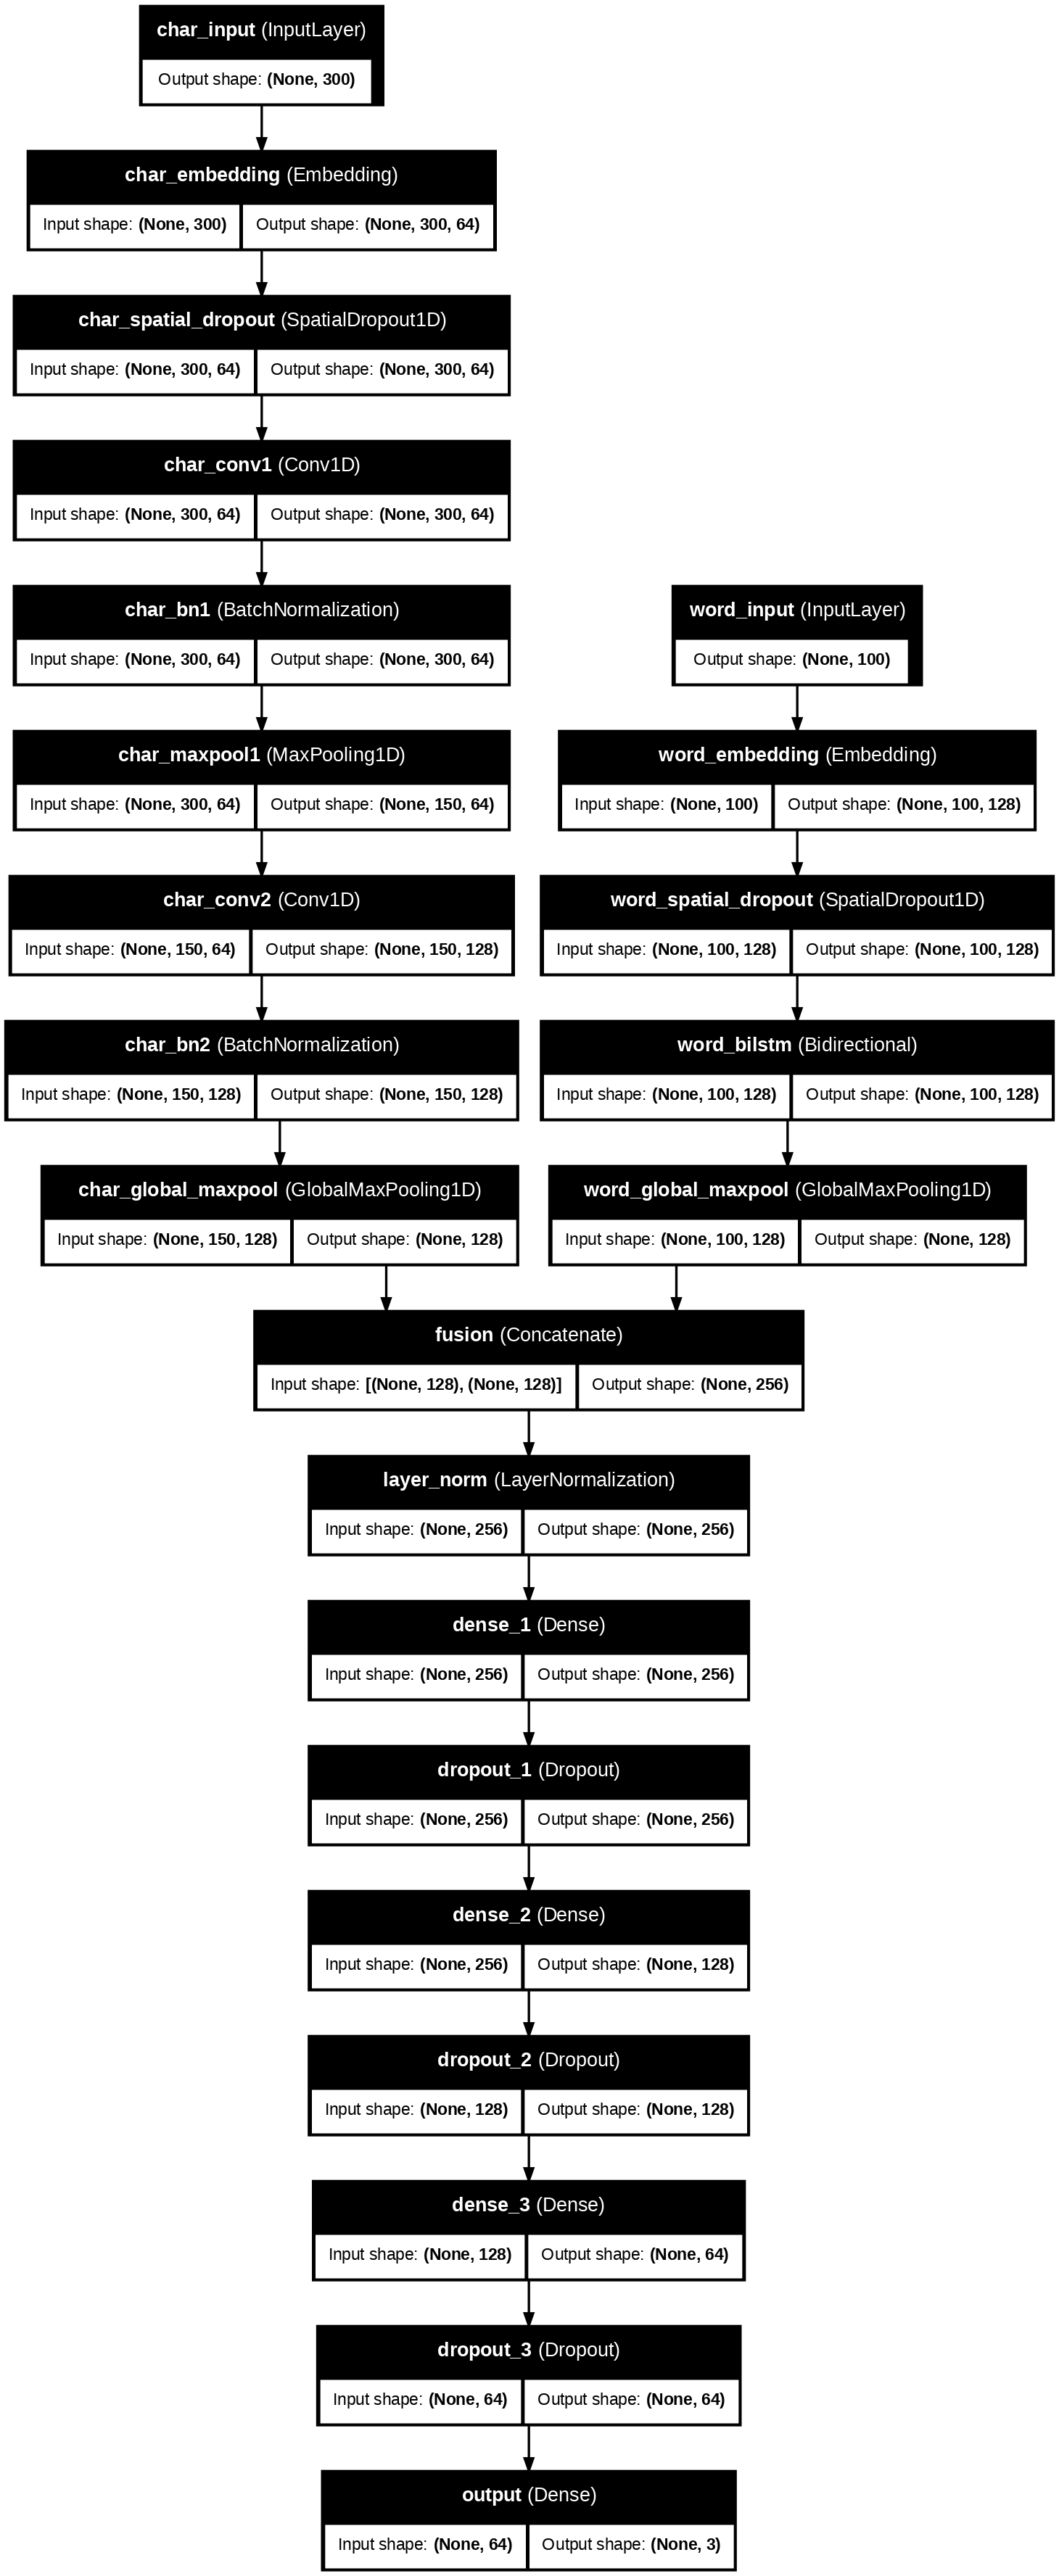

In [10]:
# ============================================================
# Simpan diagram arsitektur hybrid model sebagai gambar
# ============================================================

arch_path = f'{PLOTS_DIR}/05_hybrid_architecture.png'
os.makedirs(os.path.dirname(arch_path), exist_ok=True)

tf.keras.utils.plot_model(
    hybrid_model,
    to_file          = arch_path,
    show_shapes      = True,
    show_dtype       = False,
    show_layer_names = True,
    rankdir          = 'TB',
    expand_nested    = True,
    dpi              = 120,
)

print(f'✅ Diagram arsitektur disimpan: {arch_path}')

from IPython.display import Image
Image(arch_path)

Callbacks Training

In [11]:
# ============================================================
# Callbacks identik dengan baseline untuk perbandingan fair
# Format model disimpan dalam .keras (native Keras format)
# untuk menghindari warning legacy .h5
# ============================================================

HYBRID_MODEL_PATH_KERAS = HYBRID_MODEL_PATH.replace('.h5', '.keras')
log_path                = f'{RESULTS_DIR}/hybrid_training_log.csv'

os.makedirs(os.path.dirname(HYBRID_MODEL_PATH_KERAS), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

callbacks = [

    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1,
        mode                 = 'min',
    ),

    ModelCheckpoint(
        filepath          = HYBRID_MODEL_PATH_KERAS,
        monitor           = 'val_loss',
        save_best_only    = True,
        save_weights_only = False,
        verbose           = 1,
        mode              = 'min',
    ),

    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1,
        mode     = 'min',
    ),

    CSVLogger(
        filename = log_path,
        append   = False,
    ),
]

print('=== CALLBACKS CONFIGURED ===')
print(f'  EarlyStopping     : patience=5, monitor=val_loss')
print(f'  ModelCheckpoint   : {HYBRID_MODEL_PATH_KERAS}')
print(f'  ReduceLROnPlateau : factor=0.5, patience=3')
print(f'  CSVLogger         : {log_path}')

=== CALLBACKS CONFIGURED ===
  EarlyStopping     : patience=5, monitor=val_loss
  ModelCheckpoint   : /content/drive/MyDrive/sentiment-robustness-id/models/hybrid_model.keras
  ReduceLROnPlateau : factor=0.5, patience=3
  CSVLogger         : /content/drive/MyDrive/sentiment-robustness-id/results/hybrid_training_log.csv


 Training Hybrid Model

In [12]:
# ============================================================
# Training hybrid model
# Input: dua branch sekaligus [word_input, char_input]
# Train set → clean only (sama dengan baseline)
# ============================================================

print('=' * 52)
print('       TRAINING HYBRID MODEL')
print('=' * 52)
print(f'  Epochs       : {EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Optimizer    : Adam (lr={LEARNING_RATE})')
print(f'  Loss         : categorical_crossentropy')
print(f'  Input branch : Word + Char (dual input)')
print('=' * 52)

history = hybrid_model.fit(
    x               = [X_train_word, X_train_char],
    y               = y_train_cat,
    validation_data = ([X_val_word, X_val_char], y_val_cat),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1,
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\n✅ Training selesai')
print(f'   Epoch terbaik : {best_epoch}')
print(f'   Best val_loss : {min(history.history["val_loss"]):.4f}')
print(f'   Best val_acc  : {max(history.history["val_accuracy"]):.4f}')

       TRAINING HYBRID MODEL
  Epochs       : 20
  Batch size   : 64
  Optimizer    : Adam (lr=0.001)
  Loss         : categorical_crossentropy
  Input branch : Word + Char (dual input)
Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3699 - loss: 1.1522
Epoch 1: val_loss improved from inf to 0.75597, saving model to /content/drive/MyDrive/sentiment-robustness-id/models/hybrid_model.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.3701 - loss: 1.1519 - val_accuracy: 0.6635 - val_loss: 0.7560 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6718 - loss: 0.8567
Epoch 2: val_loss improved from 0.75597 to 0.57631, saving model to /content/drive/MyDrive/sentiment-robustness-id/models/hybrid_model.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6720 - loss: 0.8565 - val_accuracy: 0.7940 - val_loss: 0.5763 - learning_rate: 0.0010
Epoch 3/20
254/255 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7936 - los

Visualisasi & Perbandingan Learning Curve

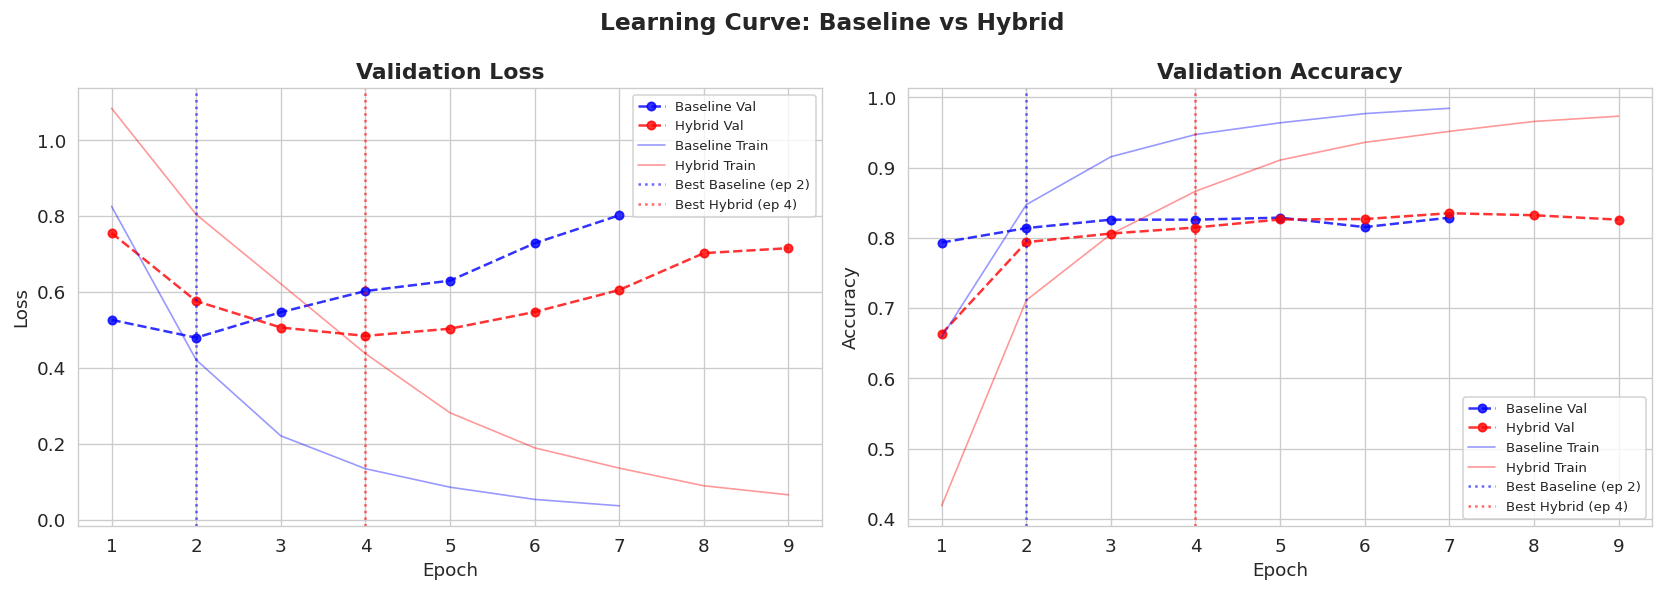

✅ Plot disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/05_learning_curve_comparison.png


In [13]:
def plot_learning_curve_comparison(
    history_baseline : dict,
    history_hybrid   : dict,
    save_path        : str,
) -> None:
    """
    Plot learning curve baseline vs hybrid dalam satu figure.
    Memudahkan perbandingan konvergensi dan stabilitas training.

    Parameters
    ----------
    history_baseline : dict — history.history dari baseline model
    history_hybrid   : dict — history.history dari hybrid model
    save_path        : str  — path simpan gambar
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Learning Curve: Baseline vs Hybrid', fontsize=14, fontweight='bold')

    epochs_b = range(1, len(history_baseline['val_loss']) + 1)
    epochs_h = range(1, len(history_hybrid['val_loss']) + 1)

    best_b   = np.argmin(history_baseline['val_loss']) + 1
    best_h   = np.argmin(history_hybrid['val_loss']) + 1

    for ax, metric, title in zip(
        axes,
        [('val_loss', 'loss'), ('val_accuracy', 'accuracy')],
        ['Validation Loss', 'Validation Accuracy'],
    ):
        val_key, train_key = metric

        ax.plot(epochs_b, history_baseline[val_key], 'b--o',
                markersize=5, alpha=0.8, label=f'Baseline Val')
        ax.plot(epochs_h, history_hybrid[val_key],   'r--o',
                markersize=5, alpha=0.8, label=f'Hybrid Val')
        ax.plot(epochs_b, history_baseline[train_key], 'b-',
                alpha=0.4, linewidth=1, label=f'Baseline Train')
        ax.plot(epochs_h, history_hybrid[train_key],   'r-',
                alpha=0.4, linewidth=1, label=f'Hybrid Train')

        ax.axvline(best_b, color='blue', linestyle=':', alpha=0.6,
                   label=f'Best Baseline (ep {best_b})')
        ax.axvline(best_h, color='red',  linestyle=':', alpha=0.6,
                   label=f'Best Hybrid (ep {best_h})')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title.split()[-1])
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot disimpan: {save_path}')


# Load history baseline dari CSV log
df_baseline_log  = pd.read_csv(f'{RESULTS_DIR}/baseline_training_log.csv')
history_baseline = {
    'loss'         : df_baseline_log['loss'].tolist(),
    'val_loss'     : df_baseline_log['val_loss'].tolist(),
    'accuracy'     : df_baseline_log['accuracy'].tolist(),
    'val_accuracy' : df_baseline_log['val_accuracy'].tolist(),
}

plot_learning_curve_comparison(
    history_baseline = history_baseline,
    history_hybrid   = history.history,
    save_path        = f'{PLOTS_DIR}/05_learning_curve_comparison.png',
)

Fungsi Evaluasi Model

In [14]:
def evaluate_on_testset(
    model       : Model,
    X_inputs    : list,
    y_true      : np.ndarray,
    label_map   : dict,
    dataset_name: str,
    batch_size  : int = 64,
) -> dict:
    """
    Evaluasi model pada satu test set.
    Mendukung single input (baseline) maupun multi-input (hybrid).

    Parameters
    ----------
    model        : trained Keras model
    X_inputs     : list of input arrays [X_word] atau [X_word, X_char]
    y_true       : label integer ground truth
    label_map    : mapping {int: str} untuk nama kelas
    dataset_name : nama dataset untuk logging
    batch_size   : batch size saat inference

    Returns
    -------
    metrics : dict — accuracy, macro_f1, weighted_f1,
                     per_class_f1, confusion_matrix
    """
    y_prob = model.predict(X_inputs, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc         = accuracy_score(y_true, y_pred)
    macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm          = confusion_matrix(y_true, y_pred)
    report      = classification_report(
        y_true, y_pred,
        target_names = [label_map[i] for i in sorted(label_map)],
        output_dict  = True,
        zero_division= 0,
    )

    per_class_f1 = {
        label_map[i]: report[label_map[i]]['f1-score']
        for i in sorted(label_map)
    }

    metrics = {
        'dataset'         : dataset_name,
        'accuracy'        : round(acc, 4),
        'macro_f1'        : round(macro_f1, 4),
        'weighted_f1'     : round(weighted_f1, 4),
        'per_class_f1'    : per_class_f1,
        'confusion_matrix': cm.tolist(),
        'report'          : report,
    }

    print(f'\n{"=" * 50}')
    print(f'  EVALUASI — {dataset_name}')
    print(f'{"=" * 50}')
    print(f'  Accuracy      : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Macro F1      : {macro_f1:.4f}')
    print(f'  Weighted F1   : {weighted_f1:.4f}')
    print(f'\n  Per-Class F1:')
    for cls, f1 in per_class_f1.items():
        print(f'    {cls:10s}: {f1:.4f}')

    return metrics

Load & Tokenisasi Noisy Test Set

In [15]:
# ============================================================
# Load semua noisy test set dari lokal Colab
# Tokenisasi dengan KEDUA tokenizer (word + char)
# ============================================================

def load_and_tokenize_noisy_dual(
    path           : str,
    word_tokenizer : Tokenizer,
    char_tokenizer : Tokenizer,
    max_word_len   : int,
    max_char_len   : int,
) -> tuple:
    """
    Load noisy test set dan tokenisasi dengan word + char tokenizer.

    Parameters
    ----------
    path           : path ke file CSV noisy test set
    word_tokenizer : tokenizer word-level (sudah di-fit di nb04)
    char_tokenizer : tokenizer char-level (di-fit di nb05)
    max_word_len   : panjang sequence word
    max_char_len   : panjang sequence char

    Returns
    -------
    X_word : np.ndarray — padded word sequences
    X_char : np.ndarray — padded char sequences
    y_true : np.ndarray — label integer
    """
    df    = pd.read_csv(path)
    texts = df['tweet_noisy'].fillna('').values
    y     = df[LABEL_COLUMN].values

    X_word = pad_sequences(
        word_tokenizer.texts_to_sequences(texts),
        maxlen=max_word_len, padding='post', truncating='post',
    )
    X_char = pad_sequences(
        char_tokenizer.texts_to_sequences(texts),
        maxlen=max_char_len, padding='post', truncating='post',
    )
    return X_word, X_char, y


print('Loading & tokenisasi noisy test sets dari lokal...\n')

Xw_clean, Xc_clean, y_clean = load_and_tokenize_noisy_dual(
    LOCAL_TEST_CLEAN_PATH, word_tokenizer, char_tokenizer, MAX_SEQ_LEN, MAX_CHAR_LEN)
Xw_n10, Xc_n10, y_n10 = load_and_tokenize_noisy_dual(
    LOCAL_TEST_NOISE_10_PATH, word_tokenizer, char_tokenizer, MAX_SEQ_LEN, MAX_CHAR_LEN)
Xw_n20, Xc_n20, y_n20 = load_and_tokenize_noisy_dual(
    LOCAL_TEST_NOISE_20_PATH, word_tokenizer, char_tokenizer, MAX_SEQ_LEN, MAX_CHAR_LEN)
Xw_n30, Xc_n30, y_n30 = load_and_tokenize_noisy_dual(
    LOCAL_TEST_NOISE_30_PATH, word_tokenizer, char_tokenizer, MAX_SEQ_LEN, MAX_CHAR_LEN)

print(f'  {"Dataset":<12} {"Word Shape":<18} {"Char Shape":<18}')
print(f'  {"-"*48}')
for name, Xw, Xc in [
    ('Clean',    Xw_clean, Xc_clean),
    ('Noise 10%', Xw_n10,  Xc_n10),
    ('Noise 20%', Xw_n20,  Xc_n20),
    ('Noise 30%', Xw_n30,  Xc_n30),
]:
    print(f'  {name:<12} {str(Xw.shape):<18} {str(Xc.shape):<18}')

# ---- Evaluasi pada semua versi ----
test_sets = [
    ('Clean (0%)', [Xw_clean, Xc_clean], y_clean),
    ('Noise 10%',  [Xw_n10,  Xc_n10],   y_n10),
    ('Noise 20%',  [Xw_n20,  Xc_n20],   y_n20),
    ('Noise 30%',  [Xw_n30,  Xc_n30],   y_n30),
]

hybrid_results = []
for name, X_inputs, y_true in test_sets:
    metrics = evaluate_on_testset(
        model        = hybrid_model,
        X_inputs     = X_inputs,
        y_true       = y_true,
        label_map    = LABEL_MAP,
        dataset_name = name,
    )
    hybrid_results.append(metrics)

Loading & tokenisasi noisy test sets dari lokal...

  Dataset      Word Shape         Char Shape        
  ------------------------------------------------
  Clean        (3495, 100)        (3495, 300)       
  Noise 10%    (3495, 100)        (3495, 300)       
  Noise 20%    (3495, 100)        (3495, 300)       
  Noise 30%    (3495, 100)        (3495, 300)       

  EVALUASI — Clean (0%)
  Accuracy      : 0.8195 (81.95%)
  Macro F1      : 0.6861
  Weighted F1   : 0.8284

  Per-Class F1:
    Negatif   : 0.4920
    Positif   : 0.9032
    Netral    : 0.6632

  EVALUASI — Noise 10%
  Accuracy      : 0.8157 (81.57%)
  Macro F1      : 0.6773
  Weighted F1   : 0.8233

  Per-Class F1:
    Negatif   : 0.4814
    Positif   : 0.9006
    Netral    : 0.6498

  EVALUASI — Noise 20%
  Accuracy      : 0.8140 (81.40%)
  Macro F1      : 0.6651
  Weighted F1   : 0.8200

  Per-Class F1:
    Negatif   : 0.4695
    Positif   : 0.9037
    Netral    : 0.6222

  EVALUASI — Noise 30%
  Accuracy      : 0.8092 

Hitung Robustness Drop Rate

In [16]:
# ============================================================
# Hitung drop rate hybrid dan bandingkan langsung
# dengan baseline untuk melihat peningkatan robustness
# ============================================================

def compute_drop_rate(score_clean: float, score_noisy: float) -> float:
    """Hitung persentase penurunan performa akibat noise."""
    if score_clean == 0:
        return 0.0
    return round((score_clean - score_noisy) / score_clean * 100, 2)


# Load hasil baseline dari CSV
df_baseline = pd.read_csv(f'{RESULTS_DIR}/metrics_baseline.csv')

acc_clean_h = hybrid_results[0]['accuracy']
f1_clean_h  = hybrid_results[0]['macro_f1']

print('=== ROBUSTNESS DROP RATE — HYBRID MODEL ===\n')
print(f'{"Dataset":<15} {"Accuracy":>10} {"Drop Acc%":>10} {"Macro F1":>10} {"Drop F1%":>10}')
print('-' * 58)

drop_summary = []
for res in hybrid_results:
    drop_acc = compute_drop_rate(acc_clean_h, res['accuracy'])
    drop_f1  = compute_drop_rate(f1_clean_h,  res['macro_f1'])
    drop_summary.append({
        'model'    : 'Hybrid',
        'dataset'  : res['dataset'],
        'accuracy' : res['accuracy'],
        'macro_f1' : res['macro_f1'],
        'drop_acc' : drop_acc,
        'drop_f1'  : drop_f1,
    })
    print(f'{res["dataset"]:<15} {res["accuracy"]:>10.4f} {drop_acc:>9.2f}% '
          f'{res["macro_f1"]:>10.4f} {drop_f1:>9.2f}%')

# Gabungkan baseline & hybrid untuk perbandingan
df_hybrid_drops   = pd.DataFrame(drop_summary)
df_combined_drops = pd.concat([df_baseline, df_hybrid_drops], ignore_index=True)
df_combined_drops.to_csv(f'{RESULTS_DIR}/metrics_hybrid.csv', index=False)

print(f'\n✅ Hasil disimpan: {RESULTS_DIR}/metrics_hybrid.csv')

# ---- Preview perbandingan langsung ----
print('\n=== PERBANDINGAN DROP RATE: BASELINE vs HYBRID ===\n')
print(f'{"Dataset":<15} {"Base Acc":>9} {"Hyb Acc":>9} {"ΔAcc":>8} '
      f'{"Base F1":>9} {"Hyb F1":>9} {"ΔF1":>8}')
print('-' * 72)

for b_row, h_row in zip(
    df_baseline.to_dict('records'),
    drop_summary
):
    delta_acc = round(h_row['accuracy'] - b_row['accuracy'], 4)
    delta_f1  = round(h_row['macro_f1'] - b_row['macro_f1'], 4)
    sign_acc  = '+' if delta_acc >= 0 else ''
    sign_f1   = '+' if delta_f1  >= 0 else ''
    print(f'{h_row["dataset"]:<15} {b_row["accuracy"]:>9.4f} {h_row["accuracy"]:>9.4f} '
          f'{sign_acc}{delta_acc:>7.4f} {b_row["macro_f1"]:>9.4f} '
          f'{h_row["macro_f1"]:>9.4f} {sign_f1}{delta_f1:>7.4f}')

=== ROBUSTNESS DROP RATE — HYBRID MODEL ===

Dataset           Accuracy  Drop Acc%   Macro F1   Drop F1%
----------------------------------------------------------
Clean (0%)          0.8195      0.00%     0.6861      0.00%
Noise 10%           0.8157      0.46%     0.6773      1.28%
Noise 20%           0.8140      0.67%     0.6651      3.06%
Noise 30%           0.8092      1.26%     0.6544      4.62%

✅ Hasil disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/metrics_hybrid.csv

=== PERBANDINGAN DROP RATE: BASELINE vs HYBRID ===

Dataset          Base Acc   Hyb Acc     ΔAcc   Base F1    Hyb F1      ΔF1
------------------------------------------------------------------------
Clean (0%)         0.8243    0.8195 -0.0048    0.7197    0.6861 -0.0336
Noise 10%          0.8203    0.8157 -0.0046    0.7101    0.6773 -0.0328
Noise 20%          0.8129    0.8140 + 0.0011    0.6971    0.6651 -0.0320
Noise 30%          0.7991    0.8092 + 0.0101    0.6817    0.6544 -0.0273


Confusion Matrix Hybrid

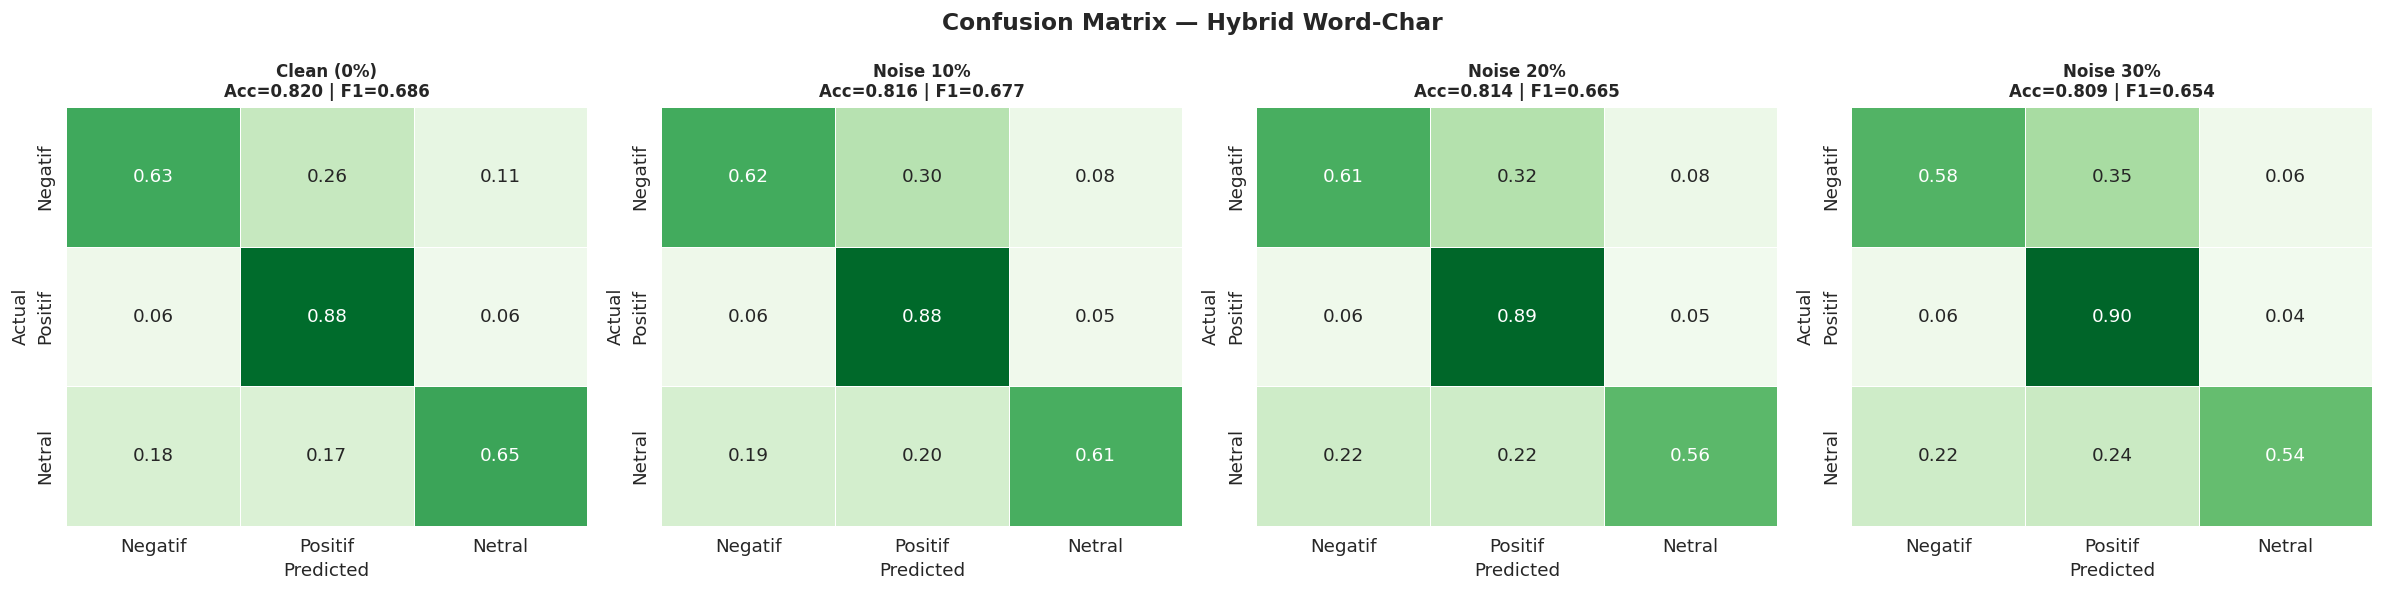

✅ Plot disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/05_hybrid_confusion_matrix.png


In [17]:
def plot_confusion_matrices(
    results   : list,
    label_map : dict,
    model_name: str,
    save_path : str,
) -> None:
    """
    Plot confusion matrix normalized per baris untuk setiap test set.
    """
    n_sets = len(results)
    fig, axes = plt.subplots(1, n_sets, figsize=(5 * n_sets, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')

    labels = [label_map[i] for i in sorted(label_map)]

    for ax, res in zip(axes, results):
        cm      = np.array(res['confusion_matrix'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm,
            annot       = True,
            fmt         = '.2f',
            cmap        = 'Greens',
            xticklabels = labels,
            yticklabels = labels,
            ax          = ax,
            linewidths  = 0.5,
            cbar        = False,
            vmin=0, vmax=1,
        )
        ax.set_title(
            f'{res["dataset"]}\nAcc={res["accuracy"]:.3f} | F1={res["macro_f1"]:.3f}',
            fontsize=10, fontweight='bold',
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot disimpan: {save_path}')


plot_confusion_matrices(
    results    = hybrid_results,
    label_map  = LABEL_MAP,
    model_name = 'Hybrid Word-Char',
    save_path  = f'{PLOTS_DIR}/05_hybrid_confusion_matrix.png',
)

Robustness Curve: Baseline vs Hybrid

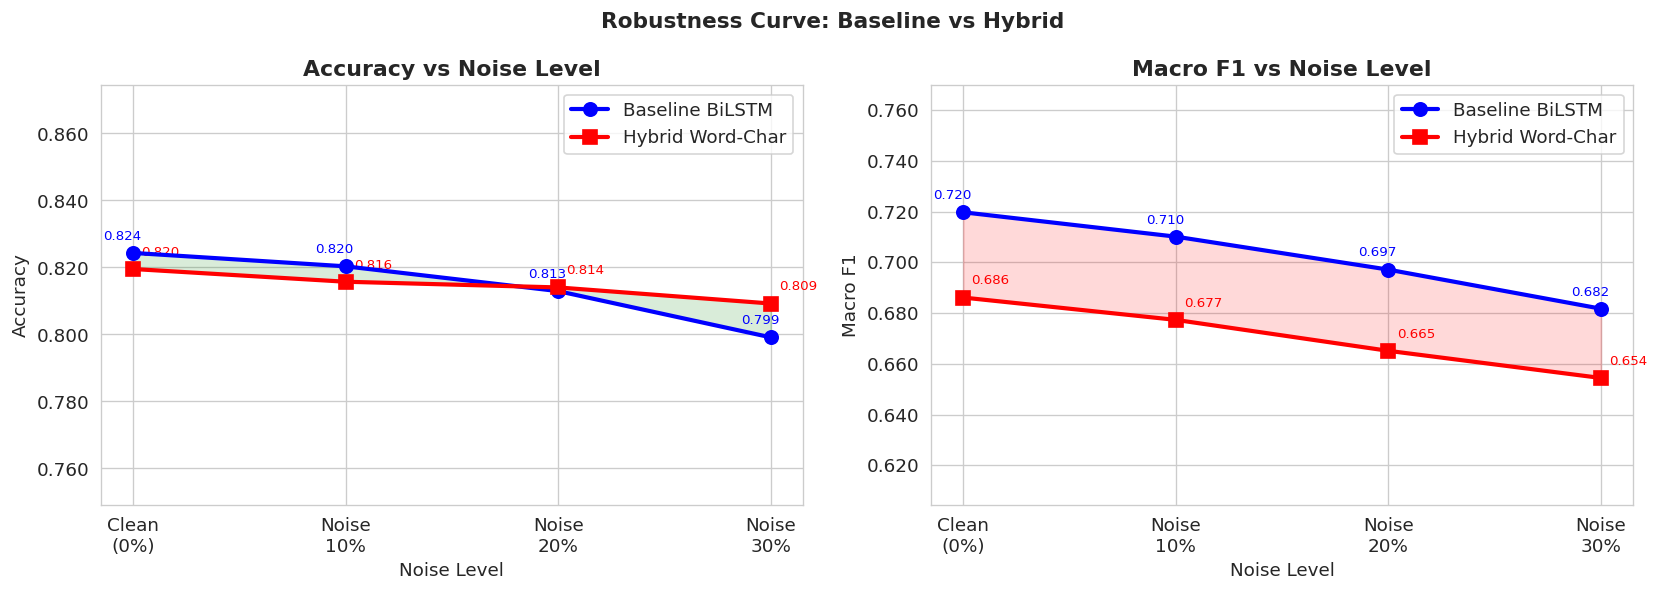

In [18]:
noise_labels = ['Clean\n(0%)', 'Noise\n10%', 'Noise\n20%', 'Noise\n30%']

acc_baseline = df_baseline['accuracy'].tolist()
f1_baseline  = df_baseline['macro_f1'].tolist()
acc_hybrid   = [r['accuracy']  for r in hybrid_results]
f1_hybrid    = [r['macro_f1']  for r in hybrid_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Robustness Curve: Baseline vs Hybrid', fontsize=13, fontweight='bold')

for ax, b_vals, h_vals, metric_name in zip(
    axes,
    [acc_baseline, f1_baseline],
    [acc_hybrid,   f1_hybrid],
    ['Accuracy', 'Macro F1'],
):
    ax.plot(noise_labels, b_vals, 'b-o', linewidth=2.5, markersize=8,
            label='Baseline BiLSTM', zorder=5)
    ax.plot(noise_labels, h_vals, 'r-s', linewidth=2.5, markersize=8,
            label='Hybrid Word-Char', zorder=5)

    # Shade area antara dua kurva
    ax.fill_between(
        range(len(noise_labels)),
        b_vals, h_vals,
        alpha=0.15,
        color='green' if h_vals[-1] >= b_vals[-1] else 'red',
    )

    # Anotasi nilai
    for i, (bv, hv) in enumerate(zip(b_vals, h_vals)):
        ax.annotate(f'{bv:.3f}', (noise_labels[i], bv),
                    textcoords='offset points', xytext=(-18, 8),
                    fontsize=8, color='blue')
        ax.annotate(f'{hv:.3f}', (noise_labels[i], hv),
                    textcoords='offset points', xytext=(5, 8),
                    fontsize=8, color='red')

    ax.set_title(f'{metric_name} vs Noise Level', fontweight='bold')
    ax.set_xlabel('Noise Level')
    ax.set_ylabel(metric_name)
    ax.legend()
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    all_vals = b_vals + h_vals
    ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.05))

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_robustness_curve_comparison.png', bbox_inches='tight')
plt.show()

Ringkasan Hybrid Model

In [19]:
best_epoch = np.argmin(history.history['val_loss']) + 1

print('=' * 60)
print('          RINGKASAN HYBRID MODEL')
print('=' * 60)
print(f'''
🏗️  ARSITEKTUR
  Model         : Hybrid Word-Character Fusion
  Word Input    : sequence (max_len={MAX_SEQ_LEN})
  Char Input    : sequence (max_len={MAX_CHAR_LEN})
  Word Branch   : Embedding → SpatialDrop → BiLSTM → GlobalMaxPool
  Char Branch   : Embedding → SpatialDrop → Conv1D×2 → GlobalMaxPool
  Fusion        : Concatenate → LayerNorm
  Head          : Dense 256 → 128 → 64 → {NUM_CLASSES} (softmax)
  Total params  : {hybrid_model.count_params():,}

📈 TRAINING
  Best epoch    : {best_epoch}
  Best val_loss : {min(history.history["val_loss"]):.4f}
  Best val_acc  : {max(history.history["val_accuracy"]):.4f}

📊 ROBUSTNESS EVALUATION
  {"Dataset":<15} {"Accuracy":>10} {"Macro F1":>10} {"Drop Acc%":>10}
  {"-"*50}''')

for row in drop_summary:
    print(f'  {row["dataset"]:<15} {row["accuracy"]:>10.4f} '
          f'{row["macro_f1"]:>10.4f} {row["drop_acc"]:>9.2f}%')

print(f'''
💾 OUTPUT
  Model saved   : {HYBRID_MODEL_PATH_KERAS}
  Metrics CSV   : {RESULTS_DIR}/metrics_hybrid.csv
  Char tokenizer: {ROOT}/models/char_tokenizer.pkl

✅ Lanjut ke 06_Evaluation.ipynb
   → Analisis statistik lengkap & paper-ready output
''')
print('=' * 60)

          RINGKASAN HYBRID MODEL

🏗️  ARSITEKTUR
  Model         : Hybrid Word-Character Fusion
  Word Input    : sequence (max_len=100)
  Char Input    : sequence (max_len=300)
  Word Branch   : Embedding → SpatialDrop → BiLSTM → GlobalMaxPool
  Char Branch   : Embedding → SpatialDrop → Conv1D×2 → GlobalMaxPool
  Fusion        : Concatenate → LayerNorm
  Head          : Dense 256 → 128 → 64 → 3 (softmax)
  Total params  : 2,806,787

📈 TRAINING
  Best epoch    : 4
  Best val_loss : 0.4846
  Best val_acc  : 0.8352

📊 ROBUSTNESS EVALUATION
  Dataset           Accuracy   Macro F1  Drop Acc%
  --------------------------------------------------
  Clean (0%)          0.8195     0.6861      0.00%
  Noise 10%           0.8157     0.6773      0.46%
  Noise 20%           0.8140     0.6651      0.67%
  Noise 30%           0.8092     0.6544      1.26%

💾 OUTPUT
  Model saved   : /content/drive/MyDrive/sentiment-robustness-id/models/hybrid_model.keras
  Metrics CSV   : /content/drive/MyDrive/sentim